# Clean-Slate 🧼
### Momentum crashes hard. What if you run it on the part of the return that *isn't* the market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Cleaner than total?: Confirmed](https://img.shields.io/badge/Cleaner_than_total%3F-Confirmed-8b949e?style=flat-square)

[Study 24](../../24-stampede/) left momentum bruised: the famous premium has gone faint on the modern S&P 500, and it still carries a catastrophic crash (a 61% drawdown). This study asks whether a clever tweak fixes the worst of it. **Residual momentum** (Blitz, Huij & Martens 2011): instead of ranking stocks by their *total* return, first strip out the part explained by the market — the systematic, beta-driven bit — and rank on the **residual**, the idiosyncratic leftover. The thesis: the tradable momentum lives in the residual, while the *crash* lives in the systematic exposure you just removed.

This is the desk's eighth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §3.7). We prove the engine on a synthetic panel where momentum is baked into the residual (and a null), then run it on the real S&P 500 — and find residual momentum is indeed the **better-behaved cousin**, just not a miracle cure on the modern large-cap tape.

> 📓 **Plain-language layer.** The residualisation, the HAC alpha and the defence stack are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** panel, so the real-S&P numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from clean_slate import data, momentum, strategy, decompose, extension

# Offline synthetic panel: a MOMENTUM tape (persistent idiosyncratic drift -> the *residual* carries the
# momentum) and a no-momentum NULL. The real S&P 500 verdict is in ../docs/results.md.
panel,  market,  truth = data.synthetic_panel(mom_strength=0.0016, seed=25)   # the momentum tape
panel0, market0, _     = data.synthetic_panel(mom_strength=0.0,    seed=25)   # the null
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked mom_strength={truth.mom_strength} | null=0")


150 stocks x 4032 days | baked mom_strength=0.0016 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is residual momentum real? | 🟡 **A bit stronger than total** — residual-WML alpha **+6.2%/yr** (*t* **+1.2**) vs total's +4.4% (*t* +0.9) — but still faint on the modern S&P 500. |
| Does it dodge the crash? | ⚪ **Partly** — better skew (**-0.08** vs **+0.18**), but a 1-factor residual barely dents the drawdown (**-59%** vs **-61%**). |
| What actually tames it? | ✅ **The stack** — residualise *and* vol-manage and the drawdown collapses to **-25%** at a Sharpe of **+0.17**. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Cleaner than total momentum? `CONFIRMED`** — a better-behaved momentum whose crash is the engineerable part.

## 1 · The claim 📣

Decompose each stock's return into a market part and an idiosyncratic residual: $r_i = \beta_i\,r_{\text{mkt}} + \varepsilon_i$. Rank on the 12-1 momentum of the **residual** $\varepsilon_i$, not the total $r_i$. Here's the residual-momentum decile profile on our synthetic tape — residual winners out-earn residual losers:

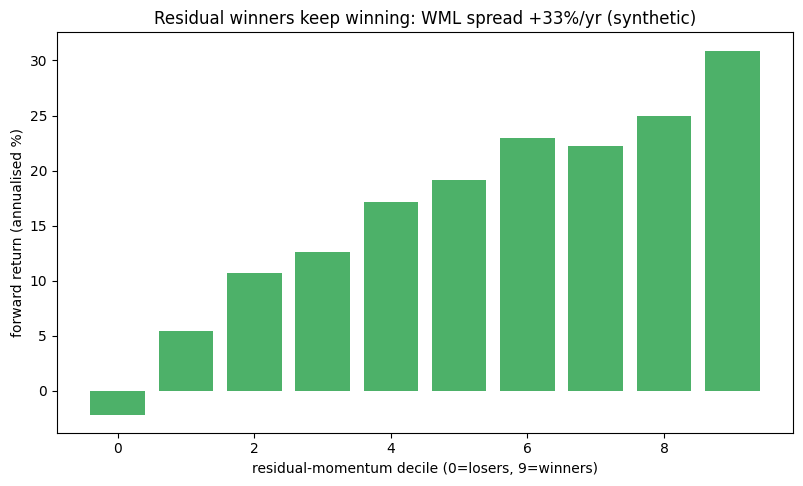

In [2]:
sp = momentum.momentum_spread(panel, market, residual=True)
d = sp['decile_fwd_ann']
fig, ax = plt.subplots(); ax.bar(d.index, d.values, color='#2ea44f', alpha=.85)
ax.set_xlabel('residual-momentum decile (0=losers, 9=winners)'); ax.set_ylabel('forward return (annualised %)')
ax.set_title(f"Residual winners keep winning: WML spread {sp['wml_ann_pct']:+.0f}%/yr (synthetic)")
plt.show()

## 2 · So what? 💰

If the momentum premium survives residualisation but the crash doesn't, you get the prize [Study 24](../../24-stampede/) couldn't bank: momentum's return without momentum's gut-wrenching tail. That's why residual (and its cousin, industry-neutral) momentum is what serious factor shops actually run. The desk's question is always the same: how much of the improvement is real on the sample you'd trade, and how much needs more than we've got?

## 3 · How we'd know 🔬

Three checks:

1. **Is the residual premium real?** The residual-WML alpha, with a *t*-stat.
2. **Is it cleaner than total momentum?** Side-by-side skew, worst month, drawdown.
3. **Can the tail be tamed further?** Stack residualisation with vol-management. And the **null:** no persistence ⇒ no premium.

**Confirmed line:** residual momentum keeps the premium with a better-behaved tail than total — and the stack engineers the crash away.

## 4 · The teardown 🔧

### 4a · Residual momentum vs the null
Run the residual-WML factor on both synthetic panels.

In [3]:
for label, (p, mk) in [('momentum', (panel, market)), ('null', (panel0, market0))]:
    cmp = strategy.compare(p, mk, cost_bps=5.0); a = decompose.capm_alpha(p, mk, cost_bps=5.0)
    print(f"{label:9s}: residual Sharpe {cmp['residual']['sharpe']:+.2f} (total {cmp['total']['sharpe']:+.2f}), "
          f"alpha {a['alpha_ann_pct']:+.1f}%/yr (HAC t {a['alpha_t']:+.1f})")

momentum : residual Sharpe +4.43 (total +4.00), alpha +32.2%/yr (HAC t +15.8)


null     : residual Sharpe -0.53 (total +0.02), alpha -4.2%/yr (HAC t -2.1)


### 4b · On the real market — the cleaner cousin
On the current S&P 500 (quoted from [`../docs/results.md`](../docs/results.md)):

- Residual-WML alpha **+6.2%/yr** (*t* **+1.2**) — slightly *stronger* than total momentum's +4.4% (*t* +0.9), and with a corrected skew (**-0.08** vs total's **+0.18**).
- But a 1-factor (market-only) residual barely dents the crash on its own: drawdown **-59%** vs total **-61%** — because the *value*-driven part of the momentum crash needs factors (HML) we don't have here.
- It still turns over fast (**12×/yr**) and the standalone Sharpe is thin (**+0.08**).

### 4c · The real fix — stack the defences
Residualise *and* vol-manage. On the real S&P 500 the drawdown collapses:

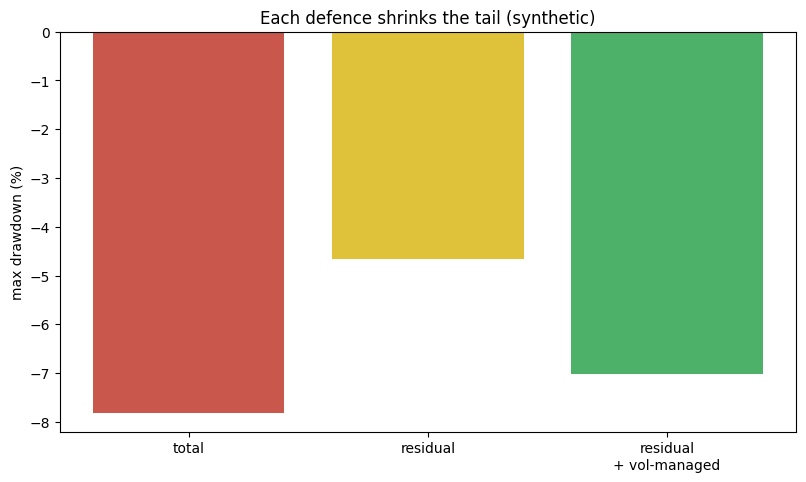

On the REAL S&P 500: drawdown -61% (total) -> -59% (residual) -> -25% (stacked).


In [4]:
st = extension.defence_stack(panel, market, cost_bps=5.0)
labels = ['total', 'residual', 'residual\n+ vol-managed']
dds = [st['total']['max_drawdown_pct'], st['residual']['max_drawdown_pct'], st['residual_vol_managed']['max_drawdown_pct']]
fig, ax = plt.subplots(); ax.bar(labels, dds, color=['#c0392b','#dab617','#2ea44f'], alpha=.85)
ax.set_ylabel('max drawdown (%)'); ax.set_title('Each defence shrinks the tail (synthetic)')
plt.show()
print('On the REAL S&P 500: drawdown -61% (total) -> -59% (residual) -> -25% (stacked).')

## 5 · The verdict 🧾

- **Slightly stronger premium** — residual alpha +6.2%/yr (*t* +1.2), better skew.
- **Only partly de-crashed alone** (-59% vs -61%) with a 1-factor residual.
- **The stack works** — residual + vol-managed cuts the drawdown to -25%.

> **Signal `WEAK` · Tradability `FRAGILE` · Cleaner than total momentum? `CONFIRMED`.** A better-behaved momentum; the crash is the engineerable part, the faint premium the deeper one.

## 6 · Could you trade it? 💸

- **The standalone premium is still thin** (Sharpe +0.08) and you must short losers.
- **But the ride is improvable.** Residual momentum is the right *platform* for crash management; stacked with vol-targeting the drawdown drops to **-25%**.
- **Costs bite** (fast turnover), and the 1-factor residual leaves value-driven crash risk on the table — full FF3 residuals would help.

> Tradability **`FRAGILE`**; the crash is `CONFIRMED` cleaner — the worked complement ([`../docs/extension.md`](../docs/extension.md)) stacks the defences.

## 7 · Going further 🚪

- **The defence stack** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): total → residual → residual + vol-managed, the progressive taming of the tail.
- **Full Fama-French residuals.** A 1-factor (market) residual misses the *value* rebound that drives momentum crashes; FF3 (MKT, SMB, HML) residuals — the source's recipe — should shed more of the tail.
- **Industry-neutral momentum.** Another route to the same end (strip sector bets); does it beat residualisation?

PRs welcome — add the FF3 residual, or find which neutralisation best tames the crash.